# Session 2: Random Forest for Wheat Yield Prediction

**Learning objectives:**
- Understand how decision trees work and why they overfit
- Learn how Random Forest (bagging) reduces overfitting
- Compare RF with OLS from Session 1 using the same features
- See how adding monthly features improves performance

**Session plan:**
1. Setup (same data as Session 1)
2. **Model 1:** RF with the same predictors as OLS
3. **Model 2:** RF with monthly features 
4. Feature importance
5. Hyperparameter tuning
6. Summary


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from scipy import stats
import statsmodels.api as sm
from sklearn.inspection import permutation_importance
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

In [6]:
DATA_PATH = './data/wheat_features.parquet' 
df = pd.read_parquet(DATA_PATH)

# Quick data overview
print("=== Column types ===")
print(f"Total columns: {len(df.columns)}")
print(f"\nTarget variable:")
print(f"  wheat_yield: {df['wheat_yield'].describe().to_string()}")


=== Column types ===
Total columns: 57

Target variable:
  wheat_yield: count    227584.000000
mean          1.797521
std           1.045510
min           0.000000
25%           0.969682
50%           1.673281
75%           2.525868
max           6.937920


In [7]:
# Flag suspect

suspect = (df['wheat_yield'] < 0.01) & (df['sowing_doy'] > 0)
print(f"Suspect zero-yield rows (sown but yield=0): {suspect.sum()}")
 
#  Window-median replacement
WINDOW = 3   # years on each side
 
def replace_zeros_window_median(series: pd.Series,
                                 suspect_mask: pd.Series,
                                 window: int = WINDOW) -> pd.Series:
    """
    For each flagged position, compute the median of up to `window`
    valid (non-zero, non-NaN) neighbours on each side in the time series.
    Falls back to the cell-wide positive median if fewer than 2 neighbours exist.
    """
    s = series.copy().astype(float)
    fallback_median = s[s > 0].median()
 
    for idx in s.index[suspect_mask.reindex(s.index, fill_value=False)]:
        pos = s.index.get_loc(idx)
 
        # Gather up to `window` values on each side, skipping zeros/NaN
        left  = [v for v in s.iloc[max(0, pos - window): pos]        if v > 0]
        right = [v for v in s.iloc[pos + 1: pos + 1 + window]        if v > 0]
        neighbours = left + right
 
        if len(neighbours) >= 2:
            s.iloc[pos] = np.median(neighbours)
        else:
            # Edge case: not enough neighbours → use cell-wide median
            s.iloc[pos] = fallback_median
 
    return s
 
 
df['wheat_yield'] = (
    df.groupby(['lat', 'lon'], group_keys=False)
    .apply(lambda g: replace_zeros_window_median(
        g['wheat_yield'],
        suspect.loc[g.index]
    ))
)


Suspect zero-yield rows (sown but yield=0): 464


In [11]:
# ── Same rescaling as Session 1 ──
df['log_wheat_yield'] = np.log(df['wheat_yield'])
df_model = df.copy()

df_model['gdd_may_nov']    = df_model['gdd_may_nov']    / 1000  # per 1000 GDD
df_model['rain_early']     = df_model['rain_early']     / 100   # per 100 mm
df_model['rain_late']      = df_model['rain_late']      / 100   # per 100 mm
df_model['rain_preseason'] = df_model['rain_preseason'] / 100   # per 100 mm
df_model['pawc_0_30_mm']   = df_model['pawc_0_30_mm']  / 100   # per 100 mm

# ── Same feature list as Session 1 OLS ──
FEATURE_COLS = ['pawc_0_30_mm',  'ph_0_30','rain_preseason', 'rain_early', 'rain_late',
                'gdd_may_nov', 'frost_days_aug_oct', 'heat_days_aug_oct',  'rad_aug_oct', 'fasw_mean_aug_oct']

TARGET_COL = 'log_wheat_yield'

# ── Same temporal split as Session 1 ──
train = df_model[df_model['year'] <= 2018]
test  = df_model[df_model['year'] >= 2019]

X_train = train[FEATURE_COLS].values.astype(np.float32)
X_test  = test[FEATURE_COLS].values.astype(np.float32)
y_train_log = train[TARGET_COL].values
y_test_log  = test[TARGET_COL].values
y_train_raw = train['wheat_yield'].values
y_test_raw  = test['wheat_yield'].values
actual_test = y_test_raw  # keep same name as Session 1

print(f"Features: {FEATURE_COLS}")
print(f"Train: {train.year.min()}-{train.year.max()}  ({len(train):,} rows)")
print(f"Test:  {test.year.min()}-{test.year.max()}   ({len(test):,} rows)")

Features: ['pawc_0_30_mm', 'ph_0_30', 'rain_preseason', 'rain_early', 'rain_late', 'gdd_may_nov', 'frost_days_aug_oct', 'heat_days_aug_oct', 'rad_aug_oct', 'fasw_mean_aug_oct']
Train: 1989-2018  (213,360 rows)
Test:  2019-2020   (14,224 rows)


---
## Model 1 — RF with Same Predictors as OLS 

In Session 1, you built a multiple linear regression using 8 simple predictors:
- `rain_preseason`, `rain_early`, `rain_late`, `pawc_0_30_mm`,  `ph_0_30`
- `gdd_may_nov`, `frost_days_aug_oct`, `heat_days_aug_oct`,  `rad_aug_oct`, `fasw_mean_aug_oct`

**Question:** Can Random Forest do better with the **exact same features**?
This is a fair comparison — same inputs, different algorithm.


In [12]:
# ── Reproduce OLS from Session 1 ──
# Same as Session 1: OLS on log(yield), then back-transform

X_train_const = sm.add_constant(train[FEATURE_COLS])
X_test_const  = sm.add_constant(test[FEATURE_COLS])

ols_model = sm.OLS(y_train_log, X_train_const).fit()

log_pred_test = ols_model.predict(X_test_const)
pred_ols_test = np.exp(log_pred_test)  # back to t/ha

# Same metrics functions as Session 1
def concordance_cc(actual, predicted):
    mean_act  = np.mean(actual)
    mean_pred = np.mean(predicted)
    var_act   = np.var(actual)
    var_pred  = np.var(predicted)
    covariance = np.mean((actual - mean_act) * (predicted - mean_pred))
    return (2 * covariance) / (var_act + var_pred + (mean_act - mean_pred)**2)

r2_ols  = r2_score(actual_test, pred_ols_test)
rmse_ols = np.sqrt(mean_squared_error(actual_test, pred_ols_test))
mae_ols  = mean_absolute_error(actual_test, pred_ols_test)
bias_ols = np.mean(pred_ols_test - actual_test)
lccc_ols = concordance_cc(actual_test, pred_ols_test)

print("=== OLS on log(yield) — Session 1 baseline ===")
print(f"  R2:   {r2_ols:.3f}")
print(f"  RMSE: {rmse_ols:.3f} t/ha")
print(f"  MAE:  {mae_ols:.3f} t/ha")
print(f"  Bias: {bias_ols:+.3f} t/ha")
print(f"  LCCC: {lccc_ols:.3f}")

=== OLS on log(yield) — Session 1 baseline ===
  R2:   0.260
  RMSE: 0.759 t/ha
  MAE:  0.601 t/ha
  Bias: +0.026 t/ha
  LCCC: 0.427


##  Single Decision Tree — Why It Overfits 

A decision tree splits the data into regions by asking yes/no questions about features. Let's see what happens with an unrestricted tree.

In [13]:
# ── Single decision tree (to show overfitting) ──
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train_raw)  # RF works on raw yield, not log

pred_tree_train = tree.predict(X_train)
pred_tree_test  = tree.predict(X_test)

print("=== Single Decision Tree (unrestricted) ===")
print(f"  Depth: {tree.get_depth()}, Leaves: {tree.get_n_leaves()}")
print(f"  Train R2: {r2_score(y_train_raw, pred_tree_train):.3f}  (near perfect!)")
print(f"  Test  R2: {r2_score(actual_test, pred_tree_test):.3f}  (much worse)")
print(f"\n  --> This gap = OVERFITTING. The tree memorised the training data.")

=== Single Decision Tree (unrestricted) ===
  Depth: 50, Leaves: 213360
  Train R2: 1.000  (near perfect!)
  Test  R2: -0.400  (much worse)

  --> This gap = OVERFITTING. The tree memorised the training data.


### From One Tree to a Forest 

**Random Forest** solves the overfitting problem by training **many trees** and averaging their predictions:

1. **Bagging:** Each tree is trained on a **random bootstrap sample** (sampling with replacement) of the training data — so each tree sees slightly different data.
2. **Feature randomness:** At each split, only a **random subset** of features is considered — so trees are decorrelated.
3. **Averaging:** Final prediction = **average** of all tree predictions.

*Averaging many slightly different ("diverse") weak models reduces variance without increasing bias — this is called ensemble learning.*

In [14]:
# ── Random Forest with same 6 features ──
rf_simple = RandomForestRegressor(
    n_estimators=500, max_depth=15, min_samples_leaf=10,
    max_features=0.5, random_state=42, n_jobs=-1
)
rf_simple.fit(X_train, y_train_raw)  # predict raw yield directly

pred_rf1_train = rf_simple.predict(X_train)
pred_rf1_test  = rf_simple.predict(X_test)

r2_rf1   = r2_score(actual_test, pred_rf1_test)
rmse_rf1 = np.sqrt(mean_squared_error(actual_test, pred_rf1_test))
mae_rf1  = mean_absolute_error(actual_test, pred_rf1_test)
bias_rf1 = np.mean(pred_rf1_test - actual_test)
lccc_rf1 = concordance_cc(actual_test, pred_rf1_test)

print("=== Random Forest (same 6 features as OLS) ===")
print(f"  R2:   {r2_rf1:.3f}")
print(f"  RMSE: {rmse_rf1:.3f} t/ha")
print(f"  MAE:  {mae_rf1:.3f} t/ha")
print(f"  Bias: {bias_rf1:+.3f} t/ha")
print(f"  LCCC: {lccc_rf1:.3f}")

=== Random Forest (same 6 features as OLS) ===
  R2:   0.316
  RMSE: 0.729 t/ha
  MAE:  0.596 t/ha
  Bias: +0.375 t/ha
  LCCC: 0.599


In [16]:
# ── Compare OLS vs RF with same features ──
print("=" * 65)
print("MODEL 1: Same features, different algorithms")
print("=" * 65)
print(f"{'Model':<25s} {'R2':>6s} {'RMSE':>7s} {'MAE':>7s} {'Bias':>7s} {'LCCC':>6s}")
print("-" * 65)
print(f"{'OLS log(y) [Session 1]':<25s} {r2_ols:6.3f} {rmse_ols:7.3f} {mae_ols:7.3f} {bias_ols:+7.3f} {lccc_ols:6.3f}")
print(f"{'Decision Tree':<25s} {r2_score(actual_test, pred_tree_test):6.3f} "
      f"{np.sqrt(mean_squared_error(actual_test, pred_tree_test)):7.3f} "
      f"{mean_absolute_error(actual_test, pred_tree_test):7.3f} "
      f"{np.mean(pred_tree_test - actual_test):+7.3f} "
      f"{concordance_cc(actual_test, pred_tree_test):6.3f}")
print(f"{'Random Forest':<25s} {r2_rf1:6.3f} {rmse_rf1:7.3f} {mae_rf1:7.3f} {bias_rf1:+7.3f} {lccc_rf1:6.3f}")

MODEL 1: Same features, different algorithms
Model                         R2    RMSE     MAE    Bias   LCCC
-----------------------------------------------------------------
OLS log(y) [Session 1]     0.260   0.759   0.601  +0.026  0.427
Decision Tree             -0.400   1.044   0.824  +0.398  0.416
Random Forest              0.316   0.729   0.596  +0.375  0.599


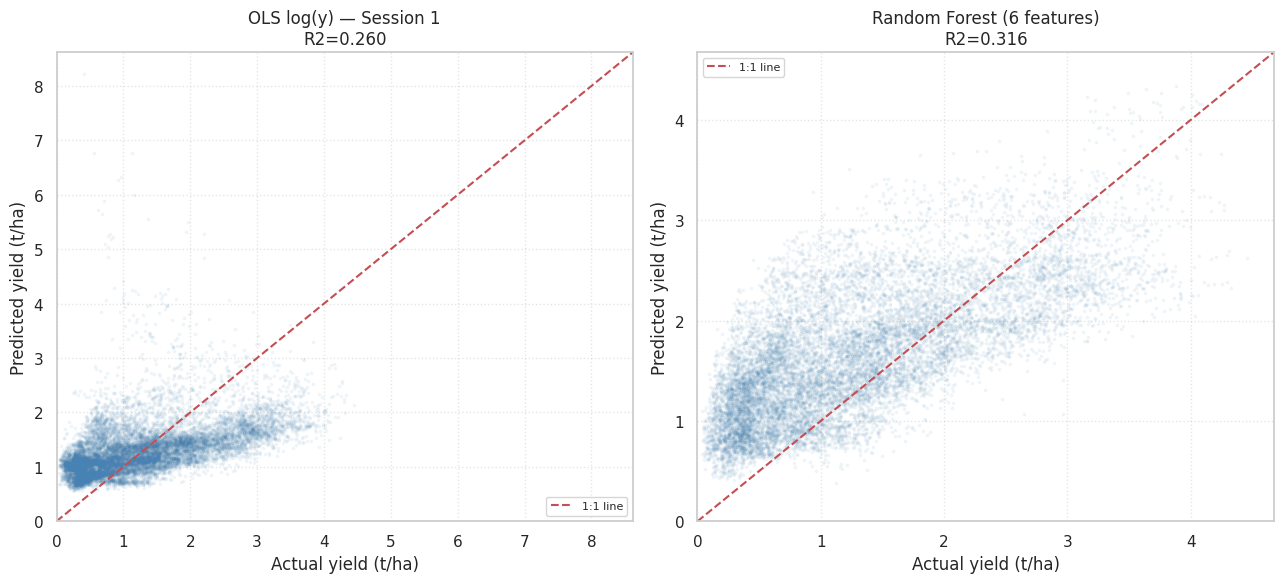

In [17]:
# ── Scatter plots (same style as Session 1) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (name, pred, r2) in zip(axes, [
    ("OLS log(y) — Session 1", pred_ols_test, r2_ols),
    ("Random Forest (6 features)", pred_rf1_test, r2_rf1),
]):
    ax.scatter(actual_test, pred, alpha=0.05, s=3, color='steelblue')
    lim = max(actual_test.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Actual yield (t/ha)')
    ax.set_ylabel('Predicted yield (t/ha)')
    ax.set_title(f'{name}\nR2={r2:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()

**Discussion Questions:**
1. How much did RF improve over OLS with the same 6 features?
2. Look at the scatter plots — where does RF do better? (low yields? high yields?)
3. The single tree had near-perfect training R² but poor test R². Why?


---
## Model 2 — RF with Monthly Features 

Now let's give the model **more temporal detail** — monthly rainfall, radiation,
soil moisture, and GDD throughout the season. This tells the model not just
*how much* rain fell, but *when* it fell.


In [18]:

# Use the UNSCALED df (RF doesn't need rescaling)
monthly_rain = [c for c in df.columns if c.startswith("rain_m") or c.startswith("rain_mpre")]
monthly_rad  = [c for c in df.columns if c.startswith("rad_sum_m")]
monthly_fasw = [c for c in df.columns if c.startswith("fasw_mean_m") and "aug" not in c]
monthly_gdd  = [c for c in df.columns if c.startswith("gdd_m")]

soil_feats   = ["pawc_0_30_mm", "ph_0_30"]
augoct_feats = [c for c in ["frost_days_aug_oct","heat_days_aug_oct",
                             "rad_aug_oct","fasw_mean_aug_oct"] if c in df.columns]

MONTHLY_FEATURES = soil_feats + monthly_rain + monthly_rad + monthly_fasw + monthly_gdd + augoct_feats
MONTHLY_FEATURES = [f for f in MONTHLY_FEATURES if f in df.columns]

print(f"Monthly feature set: {len(MONTHLY_FEATURES)} features")
print(f"  Soil:          {len(soil_feats)}")
print(f"  Monthly rain:  {len(monthly_rain)}")
print(f"  Monthly rad:   {len(monthly_rad)}")
print(f"  Monthly FASW:  {len(monthly_fasw)}")
print(f"  Monthly GDD:   {len(monthly_gdd)}")
print(f"  Aug-Oct stress: {len(augoct_feats)}")

Monthly feature set: 49 features
  Soil:          2
  Monthly rain:  15
  Monthly rad:   9
  Monthly FASW:  9
  Monthly GDD:   10
  Aug-Oct stress: 4


In [19]:
# ── Train RF with monthly features (use unscaled df) ──
train_raw = df[df['year'] <= 2018]
test_raw  = df[df['year'] >= 2019]

X_train_m = train_raw[MONTHLY_FEATURES].values.astype(np.float32)
X_test_m  = test_raw[MONTHLY_FEATURES].values.astype(np.float32)
y_train_m = train_raw['wheat_yield'].values
actual_test_m = test_raw['wheat_yield'].values

# Fill NaN
for i, c in enumerate(MONTHLY_FEATURES):
    col_vals = X_train_m[:, i]
    med = np.nanmedian(col_vals)
    X_train_m[np.isnan(X_train_m[:, i]), i] = med
    X_test_m[np.isnan(X_test_m[:, i]), i] = med

rf_monthly = RandomForestRegressor(
    n_estimators=500, max_depth=15, min_samples_leaf=10,
    max_features=0.5, random_state=42, n_jobs=-1
)
rf_monthly.fit(X_train_m, y_train_m)

pred_rf2_train = rf_monthly.predict(X_train_m)
pred_rf2_test  = rf_monthly.predict(X_test_m)

r2_rf2   = r2_score(actual_test_m, pred_rf2_test)
rmse_rf2 = np.sqrt(mean_squared_error(actual_test_m, pred_rf2_test))
mae_rf2  = mean_absolute_error(actual_test_m, pred_rf2_test)
bias_rf2 = np.mean(pred_rf2_test - actual_test_m)
lccc_rf2 = concordance_cc(actual_test_m, pred_rf2_test)

print(f"=== Random Forest ({len(MONTHLY_FEATURES)} monthly features) ===")
print(f"  R2:   {r2_rf2:.3f}")
print(f"  RMSE: {rmse_rf2:.3f} t/ha")
print(f"  MAE:  {mae_rf2:.3f} t/ha")
print(f"  Bias: {bias_rf2:+.3f} t/ha")
print(f"  LCCC: {lccc_rf2:.3f}")

=== Random Forest (49 monthly features) ===
  R2:   0.743
  RMSE: 0.447 t/ha
  MAE:  0.352 t/ha
  Bias: +0.105 t/ha
  LCCC: 0.840


In [20]:
# Comparison table
print("=" * 75)
print("FULL COMPARISON: algorithm improvement vs feature improvement")
print("=" * 75)
print(f"{'Model':<30s} {'#Feat':>5s} {'R2':>6s} {'RMSE':>7s} {'MAE':>7s} {'Bias':>7s} {'LCCC':>6s}")
print("-" * 75)
print(f"{'OLS log(y) [Session 1]':<30s} {6:>5d} {r2_ols:6.3f} {rmse_ols:7.3f} {mae_ols:7.3f} {bias_ols:+7.3f} {lccc_ols:6.3f}")
print(f"{'RF (same 6 features)':<30s} {6:>5d} {r2_rf1:6.3f} {rmse_rf1:7.3f} {mae_rf1:7.3f} {bias_rf1:+7.3f} {lccc_rf1:6.3f}")
print(f"{'RF (monthly + soil)':<30s} {len(MONTHLY_FEATURES):>5d} {r2_rf2:6.3f} {rmse_rf2:7.3f} {mae_rf2:7.3f} {bias_rf2:+7.3f} {lccc_rf2:6.3f}")
print()
print(f"Better algorithm (OLS->RF, same feat):  R2 {r2_rf1-r2_ols:+.3f}  RMSE {rmse_rf1-rmse_ols:+.3f}")
print(f"Better features  (RF 6->monthly):       R2 {r2_rf2-r2_rf1:+.3f}  RMSE {rmse_rf2-rmse_rf1:+.3f}")

FULL COMPARISON: algorithm improvement vs feature improvement
Model                          #Feat     R2    RMSE     MAE    Bias   LCCC
---------------------------------------------------------------------------
OLS log(y) [Session 1]             6  0.260   0.759   0.601  +0.026  0.427
RF (same 6 features)               6  0.316   0.729   0.596  +0.375  0.599
RF (monthly + soil)               49  0.743   0.447   0.352  +0.105  0.840

Better algorithm (OLS->RF, same feat):  R2 +0.057  RMSE -0.030
Better features  (RF 6->monthly):       R2 +0.427  RMSE -0.282


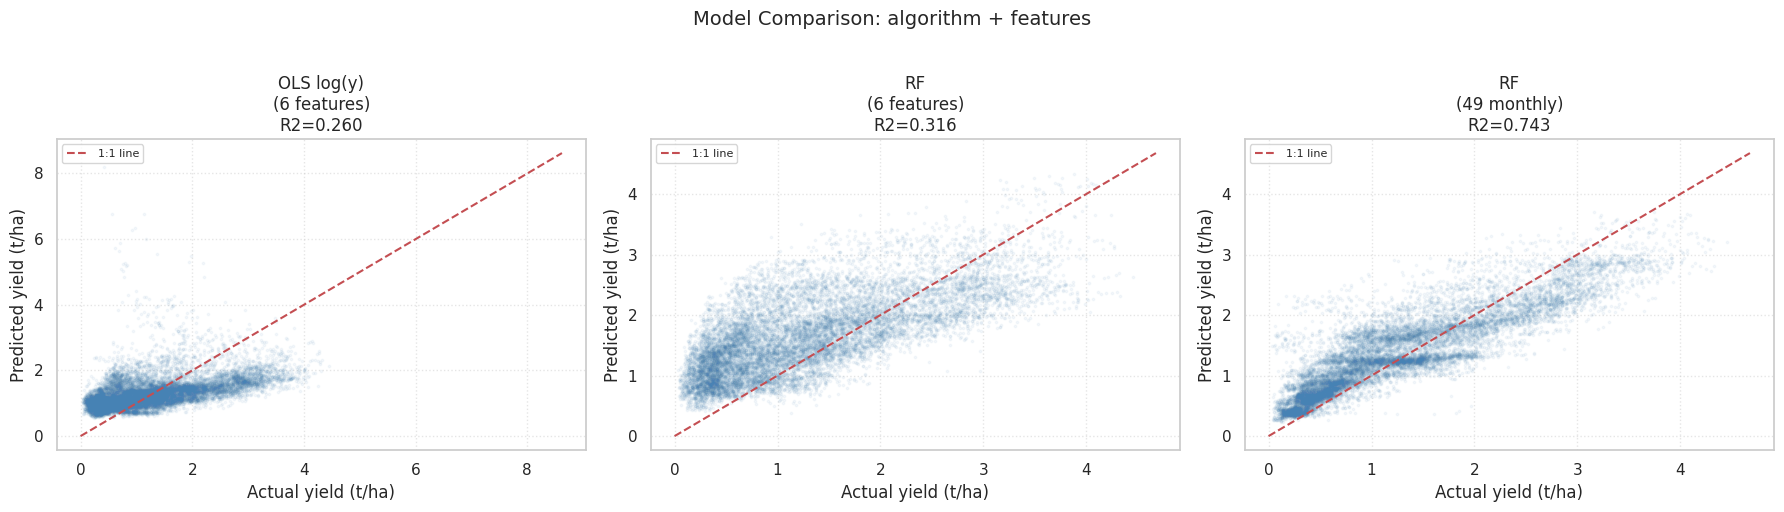

In [21]:
# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred, r2, actual) in zip(axes, [
    ("OLS log(y)\n(6 features)", pred_ols_test, r2_ols, actual_test),
    ("RF\n(6 features)", pred_rf1_test, r2_rf1, actual_test),
    (f"RF\n({len(MONTHLY_FEATURES)} monthly)", pred_rf2_test, r2_rf2, actual_test_m),
]):
    ax.scatter(actual, pred, alpha=0.05, s=3, color='steelblue')
    lim = max(actual.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Actual yield (t/ha)')
    ax.set_ylabel('Predicted yield (t/ha)')
    ax.set_title(f'{name}\nR2={r2:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Model Comparison: algorithm + features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# ── Per-year breakdown ──
test_years = test_raw['year'].values
print("=== Per-year performance ===")
for yr in [2019, 2020]:
    m = test_years == yr
    m2 = (test['year'].values == yr)
    print(f"\n  Year {yr} (n={m.sum():,}):")
    for name, pred, act in [
        ("OLS log(y)", pred_ols_test[m2], actual_test[m2]),
        ("RF (6 feat)", pred_rf1_test[m2], actual_test[m2]),
        (f"RF ({len(MONTHLY_FEATURES)} feat)", pred_rf2_test[m], actual_test_m[m]),
    ]:
        print(f"    {name:<20s} R2={r2_score(act, pred):.3f}  "
              f"RMSE={np.sqrt(mean_squared_error(act, pred)):.3f}  "
              f"Bias={np.mean(pred - act):+.3f}")

=== Per-year performance ===

  Year 2019 (n=7,112):
    OLS log(y)           R2=0.429  RMSE=0.593  Bias=+0.071
    RF (6 feat)          R2=0.209  RMSE=0.698  Bias=+0.394
    RF (49 feat)         R2=0.614  RMSE=0.488  Bias=+0.194

  Year 2020 (n=7,112):
    OLS log(y)           R2=0.103  RMSE=0.895  Bias=-0.018
    RF (6 feat)          R2=0.354  RMSE=0.759  Bias=+0.356
    RF (49 feat)         R2=0.819  RMSE=0.402  Bias=+0.015


**Discussion Questions:**
1. Which gave more improvement: better algorithm (OLS→RF) or better features (6→monthly)?
2. Which months of rainfall/FASW appear most important?
3. Does the model perform equally in 2019 and 2020?

---
## Feature Importance

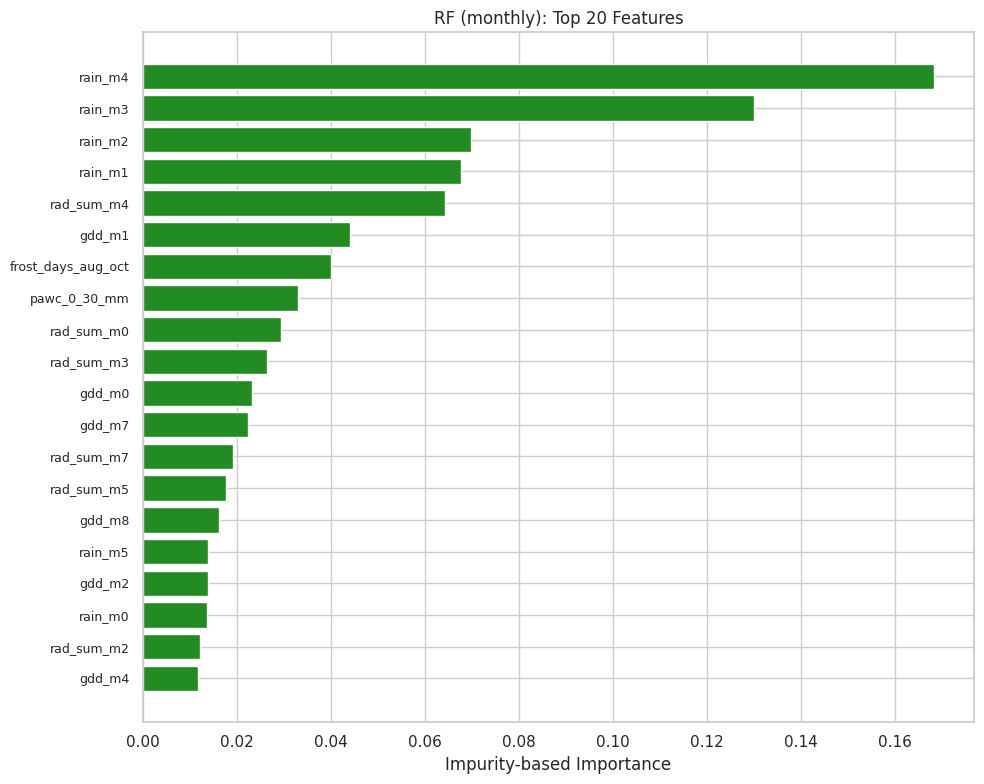

In [23]:
#  Impurity-based importance 
imp = rf_monthly.feature_importances_
idx = np.argsort(imp)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(MONTHLY_FEATURES))
top_idx = idx[:top_n]
ax.barh(range(top_n), imp[top_idx][::-1], color='forestgreen')
ax.set_yticks(range(top_n))
ax.set_yticklabels([MONTHLY_FEATURES[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel('Impurity-based Importance')
ax.set_title('RF (monthly): Top 20 Features')
plt.tight_layout()
plt.show()

Computing permutation importance...


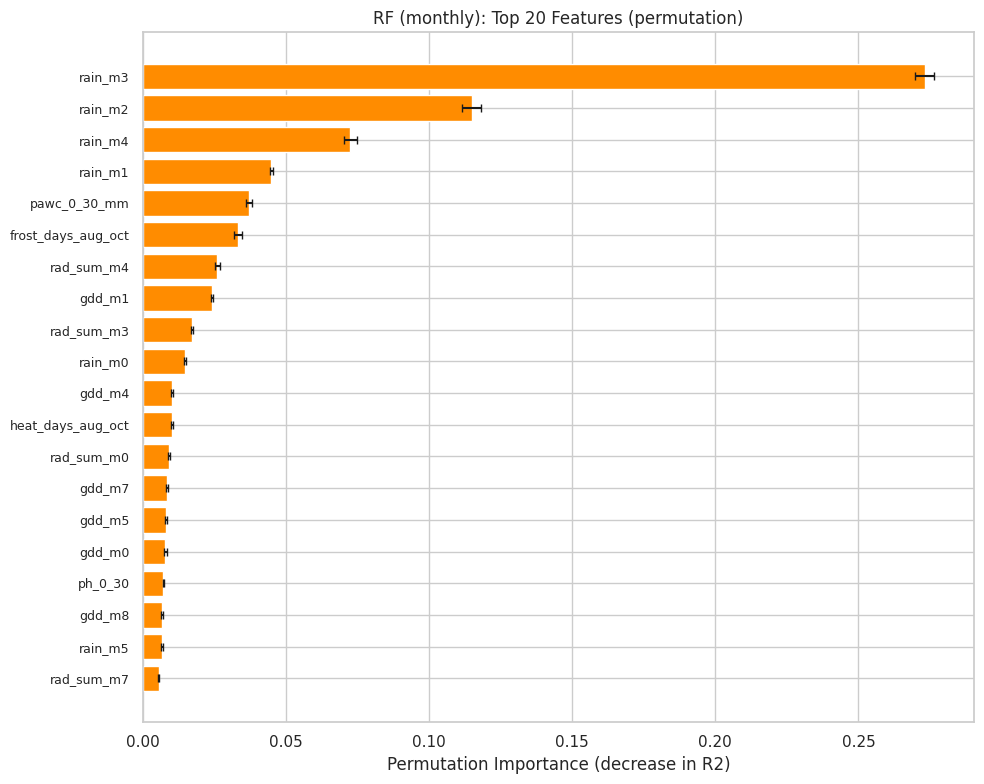

In [ ]:
# Permutation importance (more reliable) 
print("Computing permutation importance...")
perm = permutation_importance(rf_monthly, X_test_m, actual_test_m,
                               n_repeats=3, random_state=42, n_jobs=3)
perm_idx = np.argsort(perm.importances_mean)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
top_idx = perm_idx[:top_n]
ax.barh(range(top_n), perm.importances_mean[top_idx][::-1],
        xerr=perm.importances_std[top_idx][::-1], color='darkorange', capsize=3)
ax.set_yticks(range(top_n))
ax.set_yticklabels([MONTHLY_FEATURES[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel('Permutation Importance (decrease in R2)')
ax.set_title('RF (monthly): Top 20 Features (permutation)')
plt.tight_layout()
plt.show()

###  Question — Feature Importance
1. Which feature ranks highest? Is this consistent with the correlation analysis from Session 1?
2. Compare these importances with the linear regression coefficients. Are the rankings similar?
3. **Caution:** Impurity-based importance can be biased toward high-cardinality (many unique values) features. What alternative exists? (hint: permutation importance)

---
## Hyperparameter tuning

In [ ]:
from itertools import product

param_grid = {"max_depth": [8, 12, 20], "min_samples_leaf": [5, 10, 20], "max_features": [0.3, 0.5, 0.7]}
print("Tuning hyperparameters...")
best_r2, best_params, results_list = -999, {}, []

for md_val, msl, mf in product(*param_grid.values()):
    rf_t = RandomForestRegressor(n_estimators=300, max_depth=md_val, min_samples_leaf=msl,
                                  max_features=mf, random_state=42, n_jobs=-1)
    rf_t.fit(X_train_m, y_train_m)
    pred = rf_t.predict(X_test_m)
    r2 = r2_score(actual_test_m, pred)
    results_list.append({"max_depth":md_val, "min_samples_leaf":msl, "max_features":mf, "R2":round(r2,4)})
    if r2 > best_r2: best_r2 = r2; best_params = {"max_depth":md_val,"min_samples_leaf":msl,"max_features":mf}

print("\nTop 5:")
print(pd.DataFrame(results_list).sort_values("R2",ascending=False).head().to_string(index=False))
print(f"\nBest: R2={best_r2:.4f} with {best_params}")

## Summary

### What we learned

| Model | Features | Test R² | Key insight |
|-------|----------|---------|-------------|
| OLS log(y) | 10 predictors | *(from above)* |... |
| RF (same 6) | 10 predictors | *(from above)* | ... |
| RF (monthly) | ~50 | *(from above)* |...  |
---
## Exercises

1. Plot test R² vs number of trees (50, 100, 200, 500, 1000).
2. Make a spatial residual map (like Session 1) for the RF monthly model.

---
